In [1]:
from data_model.DataCleaner import *
from dl_client import DatalakeClient
from tests_utils.manage_excel_support_file import *
import pandas as pd

client = DatalakeClient()

In [14]:
search = client.query_files(
    query={'custom.level' : 'raw', 'custom.source' : 'ADNI'})
print([x['filename'] for x in search['included_files']])

['NEUROPATH_06Jun2025.csv', 'ADNIMERGE_25Jul2025.csv', 'ADSP_PHC_BIOMARKER_25Jul2025.csv', 'BLCHANGE_25Jul2025.csv', 'DXSUM_25Jul2025.csv', 'MMSE_25Jul2025.csv', 'PTDEMOG_25Jul2025.csv', 'ADNI_PICSLASHS_11Aug2025.csv', 'AMPRION_ASYN_SAA_11Aug2025.csv', 'APOERES_11Aug2025.csv', 'BAIPETNMRCFTP_08_17_22_11Aug2025.csv', 'BLENNOWCSFNFL_11Aug2025.csv', 'UCSDVOL_11Aug2025.csv', 'UCSFFSX51_ADNI1_3T_02_01_16_11Aug2025.csv', 'ADNI_BLENNOWPLASMANFLLONG_10_03_18_11Aug2025.csv', 'ADNI_BLENNOWPLASMANFL_10_03_18_11Aug2025.csv', 'BLENNOWPLASMATAU_11Aug2025.csv', 'C2N_PRECIVITYAD2_PLASMA_11Aug2025.csv', 'CSFALPHASYN_03_21_14_11Aug2025.csv', 'UCSFFSX51_11_08_19_11Aug2025.csv', 'UCSFFSX6_11Aug2025.csv', 'UCSFFSX7_11Aug2025.csv', 'UCSFFSX_11_02_15_11Aug2025.csv', 'FNIH_PLASMA_PTAU_PROJECT_11Aug2025.csv', 'PLASMA_ABETA_PROJECT_ADX_VUMC_11Aug2025.csv', 'PLASMA_ABETA_PROJECT_QUANTERIX_11Aug2025.csv', 'PLASMA_ABETA_PROJECT_ROCHE_11Aug2025.csv', 'PLASMA_ABETA_PROJECT_SHIMADZU_11Aug2025.csv', 'PLASMA_ABETA_PROJ

In [15]:

zip_files = client.download_file(
    search['object_name'],  
    extract_zip=True)

In [16]:
print(list(zip_files.keys()))
interest_list = ['UCSFFSX51', 'UCSFFSX6', 'UCSFFSX7', 'UCSFFSX']
interest_file= [x for x in list(zip_files.keys()) if x.split('_', 1)[0] in interest_list]
print(interest_file)

['NEUROPATH_06Jun2025.csv', 'ADNIMERGE_25Jul2025.csv', 'ADSP_PHC_BIOMARKER_25Jul2025.csv', 'BLCHANGE_25Jul2025.csv', 'DXSUM_25Jul2025.csv', 'MMSE_25Jul2025.csv', 'PTDEMOG_25Jul2025.csv', 'ADNI_PICSLASHS_11Aug2025.csv', 'AMPRION_ASYN_SAA_11Aug2025.csv', 'APOERES_11Aug2025.csv', 'BAIPETNMRCFTP_08_17_22_11Aug2025.csv', 'BLENNOWCSFNFL_11Aug2025.csv', 'UCSDVOL_11Aug2025.csv', 'UCSFFSX51_ADNI1_3T_02_01_16_11Aug2025.csv', 'ADNI_BLENNOWPLASMANFLLONG_10_03_18_11Aug2025.csv', 'ADNI_BLENNOWPLASMANFL_10_03_18_11Aug2025.csv', 'BLENNOWPLASMATAU_11Aug2025.csv', 'C2N_PRECIVITYAD2_PLASMA_11Aug2025.csv', 'CSFALPHASYN_03_21_14_11Aug2025.csv', 'UCSFFSX51_11_08_19_11Aug2025.csv', 'UCSFFSX6_11Aug2025.csv', 'UCSFFSX7_11Aug2025.csv', 'UCSFFSX_11_02_15_11Aug2025.csv', 'FNIH_PLASMA_PTAU_PROJECT_11Aug2025.csv', 'PLASMA_ABETA_PROJECT_ADX_VUMC_11Aug2025.csv', 'PLASMA_ABETA_PROJECT_QUANTERIX_11Aug2025.csv', 'PLASMA_ABETA_PROJECT_ROCHE_11Aug2025.csv', 'PLASMA_ABETA_PROJECT_SHIMADZU_11Aug2025.csv', 'PLASMA_ABETA_PROJ

In [38]:
file_name = 'UCSFFSX_11_02_15_11Aug2025.csv'
df = zip_files[file_name]
df_new = df.copy(deep=True)
df_new.head()

,RID,VISCODE,EXAMDATE,VERSION,LONISID,FLDSTRENG,LONIUID,IMAGEUID,RUNDATE,STATUS,...,ST98CV,ST98SA,ST98TA,ST98TS,ST99CV,ST99SA,ST99TA,ST99TS,ST9SV,update_stamp
0,2,sc,2005-08-26,2009-05-14,1945,1.5,9107,35475,2009-05-14,complete,...,3835,1622,2.077,0.746,15683,4272,3.028,0.649,4396,2015-11-02 16:47:25.0
1,3,sc,2005-09-01,2009-05-11,1948,1.5,9127,32237,2009-05-11,complete,...,3681,1734,1.942,0.696,10387,3316,2.545,0.686,3304,2015-11-02 16:47:25.0
2,3,m06,2006-03-13,2009-06-26,4081,1.5,15240,31863,2009-06-26,complete,...,4060,1868,2.051,0.723,9311,3138,2.445,0.713,3173,2015-11-02 16:47:25.0
3,3,m12,2006-09-12,2009-05-27,5186,1.5,19096,35576,2009-05-27,complete,...,3921,1898,1.969,0.739,9736,3240,2.502,0.685,3235,2015-11-02 16:47:25.0
4,3,m24,2007-09-12,2009-09-28,11918,1.5,39296,88252,2009-09-28,complete,...,4129,1915,2.020,0.707,9316,3097,2.474,0.677,3314,2015-11-02 16:47:25.0


In [39]:
keys_list = list(df_new.keys())
if 'PHASE' in keys_list:
    print('PHASE in keys_list')
else:
    print('PHASE not in keys_list')
other_list = [key for key in keys_list if key[:2] != 'ST' and not key[2].isdigit()]
print(other_list)

PHASE not in keys_list
['RID', 'VISCODE', 'EXAMDATE', 'VERSION', 'LONISID', 'FLDSTRENG', 'LONIUID', 'IMAGEUID', 'RUNDATE', 'OVERALLQC', 'TEMPQC', 'FRONTQC', 'PARQC', 'INSULAQC', 'OCCQC', 'BGQC', 'CWMQC', 'VENTQC', 'update_stamp']


In [40]:
volumes = [key for key in keys_list if  key[:2] == 'ST' and key[2].isdigit()]

code_list = ['ST37SV','ST10CV','ST24CV','ST26CV','ST29SV','ST40CV','ST96SV','ST83CV','ST85CV','ST88SV','ST99CV']
label_list = ['Left Lateral Ventricle','Estimated Intracranial Volume (ICV)','Left Entorhinal','Left Fusiform','Left Hippocampus','Left Middle Temporal','Right Lateral Ventricle','Right Entorhinal','Right Fusiform','Right Hippocampus','Right Middle Temporal']

for x, code in enumerate(code_list):
    if code in volumes:
        print(label_list[x]+' yes --> '+code)
    else:
        print(label_list[x]+' missing')

Left Lateral Ventricle yes --> ST37SV
Estimated Intracranial Volume (ICV) yes --> ST10CV
Left Entorhinal yes --> ST24CV
Left Fusiform yes --> ST26CV
Left Hippocampus yes --> ST29SV
Left Middle Temporal yes --> ST40CV
Right Lateral Ventricle yes --> ST96SV
Right Entorhinal yes --> ST83CV
Right Fusiform yes --> ST85CV
Right Hippocampus yes --> ST88SV
Right Middle Temporal yes --> ST99CV


In [32]:
# Selezioniamo solo le colonne dei volumi ICV
code_list = ['RID', 'VISCODE2','ST10CV', 'ST37SV','ST96SV','ST24CV','ST83CV','ST26CV','ST85CV','ST29SV','ST88SV','ST40CV','ST99CV']


# Creiamo il DataFrame indipendente
df_volumes = df_new[code_list].copy()

In [33]:
# Definiamo i nuovi nomi per le colonne
nuovi_nomi = {
    'ST10CV': 'ICV',
    'ST37SV': 'LVentricle',
    'ST96SV': 'RVentricle',
    'ST24CV': 'LEntorhinal',
    'ST83CV': 'REntorhinal',
    'ST26CV': 'LFusiform',
    'ST85CV': 'RFusiform',
    'ST29SV': 'LHippocampus',
    'ST88SV': 'RHippocampus',
    'ST40CV': 'LMIdTemp',
    'ST99CV': 'RMidTemp'}

# Rinominiamo le colonne
df_volumes = df_volumes.rename(columns=nuovi_nomi)
df_volumes.head()

,RID,VISCODE2,ICV,LVentricle,RVentricle,LEntorhinal,REntorhinal,LFusiform,RFusiform,LHippocampus,RHippocampus,LMIdTemp,RMidTemp
0,4225,m84,1.810883e+06,35938.4,31993.8,1401.0,1525.0,9282.0,9339.0,2868.5,3051.0,10814.0,12439.0
1,4654,m60,1.556531e+06,23985.7,24584.4,1210.0,1185.0,7900.0,8619.0,2981.6,2938.6,8995.0,8563.0
2,5230,m48,1.491851e+06,44656.2,40672.9,2068.0,1736.0,8705.0,8698.0,3700.9,3670.8,8908.0,9905.0
3,6007,m12,1.495318e+06,11273.2,10861.9,2798.0,2014.0,9910.0,11035.0,3625.8,3641.9,10163.0,12632.0
4,6066,m24,1.398508e+06,5726.7,6895.4,1866.0,1740.0,9319.0,9242.0,3651.6,3920.0,10130.0,10174.0


In [ ]:
df_volumes['Ventricles'] = df_volumes['LVentricle'] + df_volumes['RVentricle']
df_volumes['Entorhinal'] = df_volumes["LEntorhinal"]+ df_volumes["REntorhinal"]
df_volumes['Fusiform'] = df_volumes["LFusiform"]+ df_volumes["RFusiform"]
df_volumes['Hippocampus'] = df_volumes["LHippocampus"]+ df_volumes["RHippocampus"]
df_volumes['MidTemp'] = df_volumes["LMIdTemp"]+ df_volumes["RMidTemp"]
df_volumes.head()
#df_volumes[["LFusiform", "RFusiform"]].mean(axis=1)

,RID,VISCODE2,ICV,LVentricle,RVentricle,LEntorhinal,REntorhinal,LFusiform,RFusiform,LHippocampus,RHippocampus,LMIdTemp,RMidTemp,Ventricles,Entorhinal,Fusiform,Hippocampus,MidTemp
0,4225,m84,1.810883e+06,35938.4,31993.8,1401.0,1525.0,9282.0,9339.0,2868.5,3051.0,10814.0,12439.0,67932.2,2926.0,18621.0,5919.5,23253.0
1,4654,m60,1.556531e+06,23985.7,24584.4,1210.0,1185.0,7900.0,8619.0,2981.6,2938.6,8995.0,8563.0,48570.1,2395.0,16519.0,5920.2,17558.0
2,5230,m48,1.491851e+06,44656.2,40672.9,2068.0,1736.0,8705.0,8698.0,3700.9,3670.8,8908.0,9905.0,85329.1,3804.0,17403.0,7371.7,18813.0
3,6007,m12,1.495318e+06,11273.2,10861.9,2798.0,2014.0,9910.0,11035.0,3625.8,3641.9,10163.0,12632.0,22135.1,4812.0,20945.0,7267.7,22795.0
4,6066,m24,1.398508e+06,5726.7,6895.4,1866.0,1740.0,9319.0,9242.0,3651.6,3920.0,10130.0,10174.0,12622.1,3606.0,18561.0,7571.6,20304.0


In [35]:
volumes = ['Ventricles', 'Hippocampus', 'Entorhinal', 'Fusiform', 'MidTemp']
for volume in volumes:
    df_volumes[volume+'%ICV'] = (df_volumes[volume]/df_volumes['ICV'])*100
df_volumes.head()

,RID,VISCODE2,ICV,LVentricle,RVentricle,LEntorhinal,REntorhinal,LFusiform,RFusiform,LHippocampus,...,Ventricles,Entorhinal,Fusiform,Hippocampus,MidTemp,Ventricles%ICV,Hippocampus%ICV,Entorhinal%ICV,Fusiform%ICV,MidTemp%ICV
0,4225,m84,1.810883e+06,35938.4,31993.8,1401.0,1525.0,9282.0,9339.0,2868.5,...,67932.2,2926.0,18621.0,5919.5,23253.0,3.751330,0.326885,0.161579,1.028283,1.284070
1,4654,m60,1.556531e+06,23985.7,24584.4,1210.0,1185.0,7900.0,8619.0,2981.6,...,48570.1,2395.0,16519.0,5920.2,17558.0,3.120406,0.380346,0.153868,1.061270,1.128021
2,5230,m48,1.491851e+06,44656.2,40672.9,2068.0,1736.0,8705.0,8698.0,3700.9,...,85329.1,3804.0,17403.0,7371.7,18813.0,5.719679,0.494131,0.254985,1.166537,1.261051
3,6007,m12,1.495318e+06,11273.2,10861.9,2798.0,2014.0,9910.0,11035.0,3625.8,...,22135.1,4812.0,20945.0,7267.7,22795.0,1.480294,0.486031,0.321805,1.400706,1.524425
4,6066,m24,1.398508e+06,5726.7,6895.4,1866.0,1740.0,9319.0,9242.0,3651.6,...,12622.1,3606.0,18561.0,7571.6,20304.0,0.902540,0.541405,0.257846,1.327200,1.451832


In [ ]:
volumesICV = ['Ventricles%ICV', 'Hippocampus%ICV', 'Entorhinal%ICV', 'Fusiform%ICV', 'MidTemp%ICV']

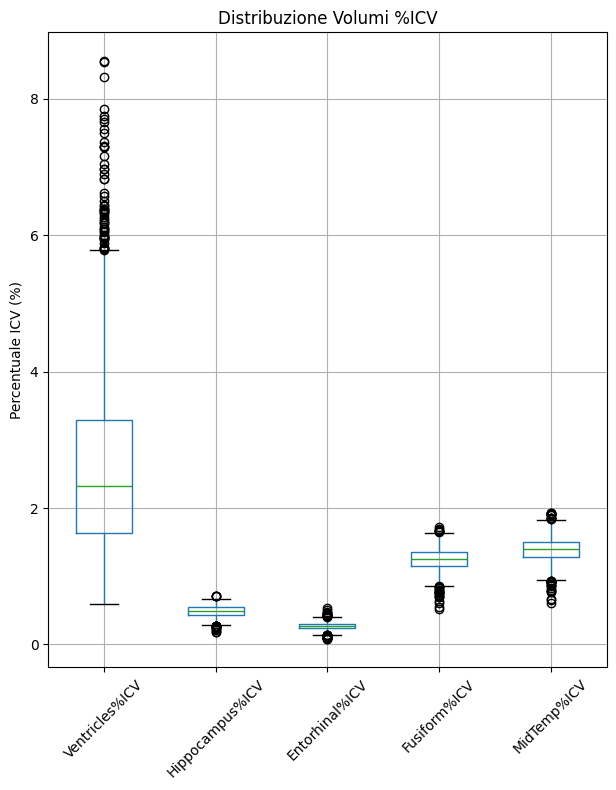

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione del plot
plt.figure(figsize=(12, 8))

# Box plot per le percentuali ICV
volumesICV = ['Ventricles%ICV', 'Hippocampus%ICV', 'Entorhinal%ICV', 'Fusiform%ICV', 'MidTemp%ICV']
df_volumesICV = df_volumes[volumesICV]

plt.subplot(1, 2, 2)
df_volumesICV.boxplot(rot=45)
plt.title('Distribuzione Volumi %ICV')
plt.ylabel('Percentuale ICV (%)')

plt.tight_layout()
plt.show()


In [37]:
# Statistiche descrittive per i volumi

print("\n=== STATISTICHE DESCRITTIVE VOLUMI %ICV ===")
print(df_volumesICV.describe())




=== STATISTICHE DESCRITTIVE VOLUMI %ICV ===
       Ventricles%ICV  Hippocampus%ICV  Entorhinal%ICV  Fusiform%ICV  \
count     2154.000000      1972.000000     1965.000000   1826.000000   
mean         2.611492         0.487002        0.270051      1.244634   
std          1.299340         0.077500        0.056922      0.155170   
min          0.588359         0.176016        0.085514      0.525870   
25%          1.632243         0.436991        0.237355      1.150855   
50%          2.319455         0.495329        0.272990      1.251290   
75%          3.292447         0.542324        0.305255      1.348984   
max          8.550066         0.714628        0.536241      1.721055   

       MidTemp%ICV  
count  2058.000000  
mean      1.388482  
std       0.179307  
min       0.607021  
25%       1.275963  
50%       1.393766  
75%       1.501625  
max       1.931520  


In [ ]:
# Calcolo del 1° e 99° percentile per ciascun volume ICV
print("=== 1° E 99° PERCENTILE PER VOLUMI %ICV ===")
print()

percentiles = [1, 99]

# Creazione di un DataFrame con i percentili per una visualizzazione più chiara
percentile_df = pd.DataFrame(index=volumesICV, columns=['1° percentile', '99° percentile'])
for volume in volumesICV:
    percentile_df.loc[volume, '1° percentile'] = df_volumesICV[volume].quantile(0.01)
    percentile_df.loc[volume, '99° percentile'] = df_volumesICV[volume].quantile(0.99)

print("=== TABELLA RIASSUNTIVA ===")
percentile_df.round(6)


=== 1° E 99° PERCENTILE PER VOLUMI %ICV ===

=== TABELLA RIASSUNTIVA ===


,1° percentile,99° percentile
Ventricles%ICV,0.766694,6.530903
Hippocampus%ICV,0.291506,0.642994
Entorhinal%ICV,0.116204,0.40236
Fusiform%ICV,0.846472,1.579309
MidTemp%ICV,0.929461,1.804767


In [ ]:
for volume in volumesICV:
    range_10 = abs(percentile_df.loc[volume, '1° percentile'] - percentile_df.loc[volume, '99° percentile'])/10
    percentile_df.loc[volume, '10% range'] = range_10
    percentile_df.loc[volume, 'max%10'] = percentile_df.loc[volume, '99° percentile'] + range_10
    percentile_df.loc[volume, 'max'] = df_volumesICV[volume].max()
    percentile_df.loc[volume, 'min%10'] = percentile_df.loc[volume, '1° percentile'] - range_10
    percentile_df.loc[volume, 'min'] = df_volumesICV[volume].min()

print("=== TABELLA RIASSUNTIVA ===")
percentile_df.round(6)

=== TABELLA RIASSUNTIVA ===


,1° percentile,99° percentile,10% range,max%10,max,min%10,min
Ventricles%ICV,0.766694,6.530903,0.576421,7.107324,8.550066,0.190274,0.588359
Hippocampus%ICV,0.291506,0.642994,0.035149,0.678143,0.714628,0.256357,0.176016
Entorhinal%ICV,0.116204,0.40236,0.028616,0.430976,0.536241,0.087588,0.085514
Fusiform%ICV,0.846472,1.579309,0.073284,1.652593,1.721055,0.773188,0.525870
MidTemp%ICV,0.929461,1.804767,0.087531,1.892297,1.931520,0.841931,0.607021


In [ ]:
# Box plot temporali per ciascun volume ICV - FIGURE SEPARATE
import matplotlib.pyplot as plt
import seaborn as sns

# Filtriamo i dati per includere solo le visite principali (0, 6, 12, 18, 24 mesi)
# Assumendo che le visite siano codificate come 'bl', 'm06', 'm12', 'm18', 'm24', ecc.
visite_principali = df_new['VISCODE'].unique().tolist()
df_temporale = df_new[df_new['VISCODE'].isin(visite_principali)].copy()


volumesICV = ['Ventricles%ICV', 'Hippocampus%ICV', 'Entorhinal%ICV', 'Fusiform%ICV', 'MidTemp%ICV']

# Creiamo una figura separata per ciascun volume ICV
for volume in volumesICV:
    plt.figure(figsize=(12, 8))
    
    # Box plot per il volume specifico usando matplotlib
    df_temporale.boxplot(column=volume, by='VISCODE', ax=plt.gca())
    plt.title(f'Distribuzione {volume} nel tempo', fontsize=14, fontweight='bold')
    plt.xlabel('Visita', fontsize=12)
    plt.ylabel('Percentuale ICV (%)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# Statistics based on DX

In [ ]:
DX_list = [0, 1, 2]
df_DX = df_new[df_new['DX'].isin(DX_list)].copy()
volumesICV = ['Ventricles%ICV', 'Hippocampus%ICV', 'Entorhinal%ICV', 'Fusiform%ICV', 'MidTemp%ICV']

# Creiamo una figura separata per ciascun volume ICV
for volume in volumesICV:
    plt.figure(figsize=(12, 8))
    
    # Box plot per il volume specifico usando matplotlib
    df_DX.boxplot(column=volume, by='DX', ax=plt.gca())
    plt.title(f'Distribuzione {volume} per diagnosi', fontsize=14, fontweight='bold')
    plt.xlabel('Diagnosi', fontsize=12)
    plt.ylabel('Percentuale ICV (%)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [ ]:
# Analisi statistica delle tendenze per ciascun volume in base alla diagnosi
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

print("=== ANALISI STATISTICA DELLE TENDENZE PER DIAGNOSI ===")
print()

volumesICV = ['Ventricles%ICV', 'Hippocampus%ICV', 'Entorhinal%ICV', 'Fusiform%ICV', 'MidTemp%ICV']

# Filtriamo i dati per includere solo le visite principali e rimuovere valori NaN nelle diagnosi
df_analisi = df_new[df_new['VISCODE'].isin(visite_principali)].copy()
df_analisi = df_analisi.dropna(subset=['DX'])

print(f"Numero di osservazioni per diagnosi:")
print(df_analisi['DX'].value_counts())
print()

# Analisi per ciascun volume
for volume in volumesICV:
    print(f"\n{'='*60}")
    print(f"ANALISI PER {volume}")
    print(f"{'='*60}")
    
    # Statistiche descrittive per diagnosi
    print(f"\n--- STATISTICHE DESCRITTIVE PER DIAGNOSI ---")
    stats_per_dx = df_analisi.groupby('DX')[volume].agg(['count', 'mean', 'std', 'min', 'max', 'median']).round(4)
    print(stats_per_dx)



In [ ]:
# Rinominazione delle colonne del DataFrame df_volumes
print("=== RINOMINAZIONE DELLE COLONNE ===")
print()

# Definiamo i nuovi nomi per le colonne
nuovi_nomi = {
    'Ventricles%ICV': 'Ventricoli_ICV',
    'Hippocampus%ICV': 'Ippocampo_ICV', 
    'Entorhinal%ICV': 'Entorinale_ICV',
    'Fusiform%ICV': 'Fusiforme_ICV',
    'MidTemp%ICV': 'Temporale_Medio_ICV'
}

# Rinominiamo le colonne
df_volumes = df_volumes.rename(columns=nuovi_nomi)

print("Colonne dopo la rinominazione:")
print(df_volumes.columns.tolist())
print(f"\nShape del DataFrame: {df_volumes.shape}")
print(f"\nPrimi 5 valori con i nuovi nomi:")
print(df_volumes.head())


In [ ]:
# Statistiche del nuovo DataFrame df_volumes
print("=== STATISTICHE DEL DATAFRAME df_volumes ===")
print()

print("Statistiche descrittive:")
print(df_volumes.describe())
print()

print("Informazioni sul DataFrame:")
print(df_volumes.info())
print()

print("Valori mancanti per colonna:")
print(df_volumes.isnull().sum())
print()

print("Memoria utilizzata dal DataFrame:")
print(f"{df_volumes.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


In [ ]:
stats_per_dx = df_analisi.groupby('DX')['MidTemp%ICV'].agg(['count', 'mean', 'std', 'min', 'max', 'median']).round(4)
stats_per_dx